图像金字塔是一种以多分辨率 来解释图像的结构，常用于图像分割、图像压缩和机器视觉 。

图像金字塔是一系列来源于同一张原始图像、以金字塔形状排列的分辨率逐步降低的图像集合 。从底层图像可以看清更多细节，从顶层图像可以看到更多的轮廓特征。通常，上层图像的宽度和高度是相邻的下层图像的 1/2。

通过对原始图像进行多尺度像素采样，生成多个不同分辨率的图像。把高分辨率的原始图像放在底部，越往上的图像越小越模糊，最小的图像放在顶部，称为图像金字塔。

向下采样，分辨率逐级降低；向上采样，分辨率逐级升高。上采样和下采样是不可逆的，将下采样的图像还原回原来尺寸时会丢失高频信息，使图片变模糊。

OpenCV 为向下采样和向上采样提供了两个函数：cv2.pyrDown 和 cv2.pyrUp。


高斯金字塔（Gaussian pyramid）

高斯金字塔（Gaussian pyramid）用于向下降采样，分辨率逐级降低。

高斯金字塔通过高斯平滑和降采样获得一系列下采样图像。首先将原图像作为最底层的图像 G0（第0层），利用高斯核（5*5）进行卷积操作，然后对卷积图像进行下采样（去除偶数行和列）得到上一层的图像 G1；重复卷积和下采样操作得到上一层图像，反复迭代，形成一个金字塔形的图像数据结构。

高斯金字塔通过上采样操作可以放大图像：先将图像的高度和宽度加倍扩充，新增的行和列以 0 填充；再用相同的卷积核（乘以 4）对扩充图像进行卷积操作，就得到放大的近似图像。上采样和下采样是不可逆的，缩放过程中存在信息丢失，因此上采样还原的图像比原始图像模糊。

OpenCV 为向下采样和向上采样提供了两个函数：cv2.pyrDown 和 cv2.pyrUp。

函数说明：

In [ ]:
函数 cv2.pyrDown 是从高分辨率的大尺寸图像逐次向下采样得到一系列图像，构建成为高斯金字塔，是一个重复高斯平滑并重新对图像采样的过程。

函数 cv2.pyrUp 对图像进行上采样和模糊。 它也可以用于拉普拉斯金字塔操作

参数说明：

src：输入图像
dst：输出图像，大小和类型与 src 相同
dstsize：输出图像的尺寸，默认为输入图像尺寸的 1/2
borderType：边界扩充的类型
注意事项：

高斯平滑的卷积核为 5*5

ValueError: could not broadcast input array from shape (552,736,3) into shape (547,730,3)

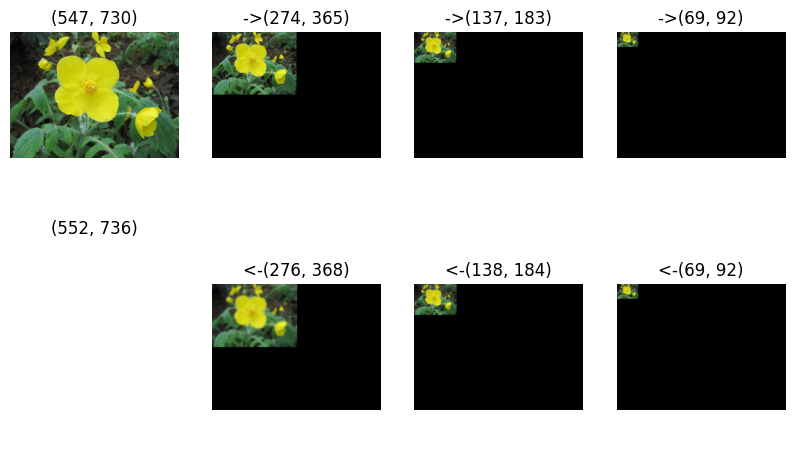

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# # 1.85：高斯图像金字塔 (Gaussian pyramid)
img = cv2.imread("../images/image0.jpg", flags=1)

# 图像向下取样
pyrD0 = img.copy()
pyrD1 = cv2.pyrDown(pyrD0)
pyrD2 = cv2.pyrDown(pyrD1)
pyrD3 = cv2.pyrDown(pyrD2)

# 图像向上取样
pyrU3 = pyrD3.copy()
pyrU2 = cv2.pyrUp(pyrU3)
pyrU1 = cv2.pyrUp(pyrU2)
pyrU0 = cv2.pyrUp(pyrU1)

plt.figure(figsize=(10, 6))
plt.subplot(244), plt.axis('off'), plt.title("->"+str(pyrD3.shape[:2]))
down3 = np.zeros_like(img, dtype=np.uint8)
down3[:pyrD3.shape[0],:pyrD3.shape[1],:] = pyrD3
plt.imshow(cv2.cvtColor(down3, cv2.COLOR_BGR2RGB))
plt.subplot(243), plt.axis('off'), plt.title("->"+str(pyrD2.shape[:2]))
down2 = np.zeros_like(img, dtype=np.uint8)
down2[:pyrD2.shape[0],:pyrD2.shape[1],:] = pyrD2
plt.imshow(cv2.cvtColor(down2, cv2.COLOR_BGR2RGB))
plt.subplot(242), plt.axis('off'), plt.title("->"+str(pyrD1.shape[:2]))
down1 = np.zeros_like(img, dtype=np.uint8)
down1[:pyrD1.shape[0],:pyrD1.shape[1],:] = pyrD1
plt.imshow(cv2.cvtColor(down1, cv2.COLOR_BGR2RGB))
plt.subplot(241), plt.axis('off'), plt.title(str(pyrD0.shape[:2]))
plt.imshow(cv2.cvtColor(pyrD0, cv2.COLOR_BGR2RGB))

plt.subplot(248), plt.axis('off'), plt.title("<-"+str(pyrU3.shape[:2]))
up3 = np.zeros_like(img, dtype=np.uint8)
up3[:pyrU3.shape[0],:pyrU3.shape[1],:] = pyrU3
plt.imshow(cv2.cvtColor(up3, cv2.COLOR_BGR2RGB))
plt.subplot(247), plt.axis('off'), plt.title("<-"+str(pyrU2.shape[:2]))
up2 = np.zeros_like(img, dtype=np.uint8)
up2[:pyrU2.shape[0],:pyrU2.shape[1],:] = pyrU2
plt.imshow(cv2.cvtColor(up2, cv2.COLOR_BGR2RGB))
plt.subplot(246), plt.axis('off'), plt.title("<-"+str(pyrU1.shape[:2]))
up1 = np.zeros_like(img, dtype=np.uint8)
up1[:pyrU1.shape[0],:pyrU1.shape[1],:] = pyrU1
plt.imshow(cv2.cvtColor(up1, cv2.COLOR_BGR2RGB))
plt.subplot(245), plt.axis('off'), plt.title(str(pyrU0.shape[:2]))
up0 = np.zeros_like(img, dtype=np.uint8)
up0[:pyrU0.shape[0],:pyrU0.shape[1],:] = pyrU0
plt.imshow(cv2.cvtColor(up0, cv2.COLOR_BGR2RGB))
plt.tight_layout()
plt.show()

In [2]:


np.set_printoptions(
    linewidth=120,   # 行宽，确保一行能放下10个数字
    formatter={'int': lambda x: f'{x:3d}'}  # 每个整数占3位，右对齐
)

image_1 = np.random.randint(0, 255, size=100, dtype=np.uint8)
iamge_1 = image_1.reshape(10, 10)
print("=======================原始图片======================")
#  显示一下原始矩阵
iamge_1

=======================原始图片======================


array([[230, 168, 235,  94, 135, 116, 150, 212, 183,  37],
       [184, 193, 226, 137,  79, 129, 182, 212,  76, 170],
       [118,  79, 151,  50, 156, 105, 137,   2, 148, 196],
       [120, 244, 154, 226, 116, 128, 215, 210,  42, 254],
       [ 74,  40, 153,  15, 172,  46,  98,  76,  60, 203],
       [212, 100,  31, 104, 103, 252, 250, 230,  45, 131],
       [ 20, 139,  66, 198,  52,   6, 151,  79, 176, 188],
       [174,  31, 220, 200, 201,  78, 170, 228,  97,   2],
       [ 12,  60,  67, 207,   5, 242, 171, 187, 228, 161],
       [201, 173,  75, 153,   5,  13,  57, 157, 136,  50]], dtype=uint8)

In [46]:
print("=======================金字塔之后======================")
image_2 = iamge_1.copy()
image_2 = cv2.pyrDown(image_2)
image_2

=======================金字塔之后======================


array([[130, 147, 120,  96, 123],
       [146, 132, 109, 100, 132],
       [134, 115, 101, 107, 154],
       [114, 113, 121, 132, 123],
       [ 90,  96, 116, 138, 133]], dtype=uint8)

In [47]:
print("=======================手动处理======================")

# 创建一个5x5的高斯卷积核

kernel = np.array([[1, 4, 6, 4, 1],
                  [4, 16, 24, 16, 4],
                  [6, 24, 36, 24, 6],
                  [4, 16, 24, 16, 4],
                  [1, 4, 6, 4, 1]])
kernel = kernel / 256
kernel

=======================手动处理======================


array([[0.00390625, 0.015625  , 0.0234375 , 0.015625  , 0.00390625],
       [0.015625  , 0.0625    , 0.09375   , 0.0625    , 0.015625  ],
       [0.0234375 , 0.09375   , 0.140625  , 0.09375   , 0.0234375 ],
       [0.015625  , 0.0625    , 0.09375   , 0.0625    , 0.015625  ],
       [0.00390625, 0.015625  , 0.0234375 , 0.015625  , 0.00390625]])

In [50]:
image_3 = iamge_1.copy()
image_3 = cv2.filter2D(image_3, -1, kernel)

image_3

array([[130, 136, 147, 143, 120, 100,  96, 105, 123, 133],
       [136, 138, 141, 136, 116,  98,  96, 108, 124, 132],
       [146, 140, 132, 123, 109,  97, 100, 116, 132, 137],
       [146, 138, 123, 112, 103,  97, 104, 126, 148, 157],
       [134, 128, 115, 105, 101, 101, 107, 126, 154, 167],
       [121, 117, 111, 108, 110, 114, 117, 125, 140, 147],
       [114, 113, 113, 115, 121, 127, 132, 131, 123, 118],
       [107, 107, 107, 113, 122, 129, 139, 140, 123, 109],
       [ 90,  91,  96, 106, 116, 123, 138, 147, 133, 121],
       [ 79,  82,  91, 104, 112, 120, 137, 149, 139, 128]], dtype=uint8)

In [55]:

dst = np.zeros_like(image_2, dtype=np.uint8)
for i in range(image_3.shape[0]):
    if i % 2 == 0:
        for j in range(image_3.shape[1]):
            if j % 2 == 0:
                dst[int(i/2), int(j/2)] = image_3[i, j]

dst

array([[130, 147, 120,  96, 123],
       [146, 132, 109, 100, 132],
       [134, 115, 101, 107, 154],
       [114, 113, 121, 132, 123],
       [ 90,  96, 116, 138, 133]], dtype=uint8)

In [56]:
print("判断调用OpenCV和numpy的函数，得到的金字塔下采样是否一样")

image_2 == dst

判断调用OpenCV和numpy的函数，得到的金字塔下采样是否一样


array([[ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True]])